In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras.utils as ku
from wordcloud import WordCloud
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


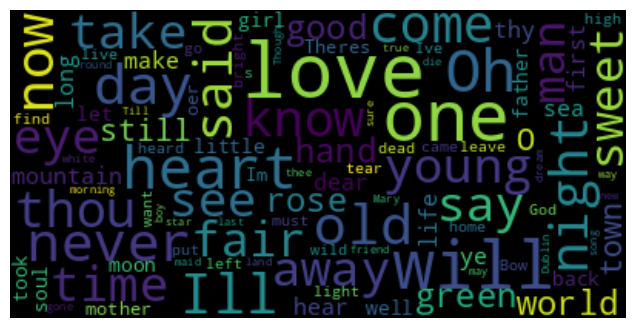

In [ ]:
# Reading the text data file
data = open('/content/drive/MyDrive/topic_3_nlp_text_generation/poem.txt', encoding="utf8").read()

# EDA: Generating WordCloud to visualize
# the text
wordcloud = WordCloud(max_font_size=50,
                      max_words=100,
                      background_color="black").generate(data)

# Plotting the WordCloud
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig("WordCloud.png")
plt.show()

In [ ]:
# Generating the corpus by
# splitting the text into lines
corpus = data.lower().split("\n")
print(corpus[:10])

['stay, i said', 'to the cut flowers.', 'they bowed', 'their heads lower.', 'stay, i said to the spider,', 'who fled.', 'stay, leaf.', 'it reddened,', 'embarrassed for me and itself.', 'stay, i said to my body.']


In [ ]:
# Fitting the Tokenizer on the Corpus
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)

# Vocabulary count of the corpus
total_words = len(tokenizer.word_index)

# the more unique words we have in the corpus
# the heavier our text generation model is going to be to train and use
print("Total Words:", total_words)

Total Words: 3807


In [ ]:
# Converting the text into embeddings (vectorized representations)
input_sequences = []
for line in corpus:
	token_list = tokenizer.texts_to_sequences([line])[0]

	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)

# calculate the longest sequence in the data
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences,
										maxlen=max_sequence_len,
										padding='pre'))

predictors, label = input_sequences[:, :-1], input_sequences[:, -1]
label = ku.to_categorical(label, num_classes=total_words+1)

In [ ]:
# Building a Bi-Directional LSTM Model
model = Sequential()

# embedding layer, input = total words, output 100 nodes
# this suggests a huge simplifcation of the corpus
# might be a good idea to increase this, however, it also adds
# complexity
model.add(Embedding(total_words + 1, 100,
					input_length=max_sequence_len-1))

# bidirectional LSTM -> to handle context for both ways
# => context of previous words and context of future words
model.add(Bidirectional(LSTM(150, return_sequences=True)))

# some extra layers for optimization
model.add(Dropout(0.2))
model.add(LSTM(100))

# a dense network with reqularization
# SMALL FIX: wrap the amount of nodes into int(), so
# that the division by 2 does not result in decimals
# amount of nodes has to be an even integer
model.add(Dense(int(total_words+1/2), activation='relu',
				kernel_regularizer=regularizers.l2(0.01)))


model.add(Dense(total_words + 1, activation='softmax'))

# compile the model
model.compile(loss='categorical_crossentropy',
			optimizer='adam', metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(predictors, label, epochs=150, verbose=1)

Epoch 1/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 204s 382ms/step - accuracy: 0.0611 - loss: 7.3196
Epoch 2/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 213s 404ms/step - accuracy: 0.0622 - loss: 6.5125
Epoch 3/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 259s 398ms/step - accuracy: 0.0648 - loss: 6.3256
Epoch 4/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 269s 411ms/step - accuracy: 0.0713 - loss: 6.2065
Epoch 5/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 254s 395ms/step - accuracy: 0.0795 - loss: 6.1170
Epoch 6/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 203s 397ms/step - accuracy: 0.0749 - loss: 6.0706
Epoch 7/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 270s 413ms/step - accuracy: 0.0788 - loss: 5.9904
Epoch 8/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 203s 398ms/step - accuracy: 0.0902 - loss: 5.8960
Epoch 9/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 203s 397ms/step - accuracy: 0.0964 - loss: 5.7955
Epoch 10/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 270s 412ms/step - accuracy: 0.1034 - loss: 5.6831
Epoch 11/150
510/510 ━━━━━━━━━━━━━━━━━━━━ 254s 396ms/step - accuracy: 0.1045 - loss: 5.62

In [ ]:
# the starting point of the the model on top of which
# new words are going to be added (similar to prompt in LLMs)
seed_text = "Soul"

# how many words we wish to generate
next_words = 15
ouptut_text = ""

# loop 25 times to create new words to extend
# the original seed text
for _ in range(next_words):
    # convert the current seed text into vectors + padding
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list], maxlen=max_sequence_len - 1,
        padding='pre')

    # predict the next most probable word based on current seed text
    predicted = np.argmax(model.predict(token_list,
                                        verbose=0), axis=-1)
    # initalize next word
    output_word = ""

    # find the predicted word in the tokenizer
    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    # finally, add the new predicted word into the end of
    # the current seed text
    seed_text += " " + output_word
    print(seed_text)

# print the result generated by the model
print("\n-- THE FINAL OUTPUT --")
print(seed_text)